# ValuingH0M3 

It is a notebook where you will find an EDA workflow about the dataset "USA Real Estate Dataset" in which we have variables such as : 
1. bath
2. bed 
3. acre_lot 
4. house_size 
5. status
6. city    
7. state 
8. prev_sold_date 

All of these features will help us to predict a variable which is 'price', and we consider it is relevant in the context of a small/medium size inmobiliary estabilished company in the U.S that based on these features (that are pretty easy and common to get) have and approximation about the value of a property. 

## Read the data and become into a dataframe using pandas 

In [2]:

import pandas as pd 

data = pd.read_csv("Real_Estate_Sales_2001-2024_GL_20260814.csv")

# Verifing with the first five samples
data.head()

/tmp/ipykernel_28538/1435552656.py:3: DtypeWarning: Columns (7,8,9,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Real_Estate_Sales_2001-2024_GL_20260814.csv")


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location
0,24079,2024,09/26/2025,Ashford,SECKAR RD,"$54,460.00","$95,000.00",0.5732,Vacant Land,NaN,NaN,MBL 23 D 4,NaN,NaN
1,240171,2024,06/06/2025,Berlin,251400,"$251,400.00","$350,000.00",0.7182,Commercial,NaN,25 - Other,NaN,NaN,NaN
2,24071,2024,12/31/2024,Bethel,25.5 TAYLOR AVENUE,"$221,480.00","$480,000.00",0.4614,Residential,Two Family,NaN,NaN,NaN,NaN
3,24018,2024,12/18/2024,Columbia,PINE STREET,"$3,640.00","$15,000.00",0.242667,Vacant Land,NaN,NaN,VACANT LAND,NaN,NaN
4,240008,2024,10/11/2024,Cromwell,BIRCH COURT,"$96,950.00","$179,900.00",0.5389,Residential,Condo,NaN,NaN,NaN,NaN


## Normalize fields and remove duplicated rows before partitioning

### Remove duplicated rows and keeping the first apariance

In [3]:
print("This is the length of the dataframe before removing duplicates:", len(data))
data = data.drop_duplicates(keep='first')
print("This is the length of the dataset after removing duplicated rows:", len(data))


This is the length of the dataframe before removing duplicates: 1188997
This is the length of the dataset after removing duplicated rows: 1188997


### Remove unnecesaary features that goes beyond the project scope

In the case of address it is because it has a high cardinality, so almost each house as a diferente one. 

In [4]:

columns_delete = ['Location','Assessor Remarks','OPM remarks', 'Address', 'Non Use Code']

data = data.drop(columns=columns_delete)

data.head()

,Serial Number,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,24079,2024,09/26/2025,Ashford,"$54,460.00","$95,000.00",0.5732,Vacant Land,NaN
1,240171,2024,06/06/2025,Berlin,"$251,400.00","$350,000.00",0.7182,Commercial,NaN
2,24071,2024,12/31/2024,Bethel,"$221,480.00","$480,000.00",0.4614,Residential,Two Family
3,24018,2024,12/18/2024,Columbia,"$3,640.00","$15,000.00",0.242667,Vacant Land,NaN
4,240008,2024,10/11/2024,Cromwell,"$96,950.00","$179,900.00",0.5389,Residential,Condo


### Becoming all monetary features into numbers 

In [5]:
columns = ['Assessed Value','Sale Amount']
for column in columns: 
    data[column] =  data[column].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

data.head()



,Serial Number,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,24079,2024,09/26/2025,Ashford,54460.0,95000.0,0.5732,Vacant Land,NaN
1,240171,2024,06/06/2025,Berlin,251400.0,350000.0,0.7182,Commercial,NaN
2,24071,2024,12/31/2024,Bethel,221480.0,480000.0,0.4614,Residential,Two Family
3,24018,2024,12/18/2024,Columbia,3640.0,15000.0,0.242667,Vacant Land,NaN
4,240008,2024,10/11/2024,Cromwell,96950.0,179900.0,0.5389,Residential,Condo


### Creating new "features" from old

Actually it is just the process of becoming a feature as Date Recorded into 3 features 'Day Recorded','Month Recorded' and 'Year Recorded'. It help us to treat it as a number while having the opportunity to check correlation between Day/Month or Month/Year when EDA stage. 

In [6]:
data['Date Recorded'] = pd.to_datetime(
    data['Date Recorded'],
    errors='coerce'
)

data['Year Recorded'] = data['Date Recorded'].dt.year
data['Month Recorded'] = data['Date Recorded'].dt.month
data['Day Recorded'] = data['Date Recorded'].dt.day

In [7]:

data = data.drop('Date Recorded', axis=1)
data.head()

,Serial Number,List Year,Town,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,95000.0,0.5732,Vacant Land,NaN,2025.0,9.0,26.0
1,240171,2024,Berlin,251400.0,350000.0,0.7182,Commercial,NaN,2025.0,6.0,6.0
2,24071,2024,Bethel,221480.0,480000.0,0.4614,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,15000.0,0.242667,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,179900.0,0.5389,Residential,Condo,2024.0,10.0,11.0


### Delete samples that don't have objetive variable Sale Amount

In [8]:
data = data.dropna(subset=['Sale Amount'])
print("This is now the new length of the dataset: ",len(data))

This is now the new length of the dataset:  1188997


## Partitioning the dataset 

In [9]:
!pip install scikit-learn


In [10]:
from sklearn.model_selection import train_test_split

y = data['Sale Amount']
X = data.drop(columns=['Sale Amount','Sales Ratio'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77)

## Minimal Imputing without EDA

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline



categorical_columns= ['Town','Property Type','Residential Type']
numerical_columns = [column for column in X.columns if column not in categorical_columns]


minimal_preprocessing = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline(steps=[
                (
                    'imputer',
                    SimpleImputer(
                        strategy='constant',
                        fill_value='Missing'
                    )
                ),
                (
                    'onehot',
                    OneHotEncoder(
                        handle_unknown='ignore'
                    )
                )
            ]),
            categorical_columns
        ),
        (
            'numerical',
            SimpleImputer(strategy='median'),
            numerical_columns
        )
    ]
)

X_train_minimal = minimal_preprocessing.fit_transform(X_train)
X_test_minimal = minimal_preprocessing.transform(X_test)

# Get and print what we got after minimal imputer

print(X_train_minimal.shape)
print(X_test_minimal.shape)
result_columns = (minimal_preprocessing.get_feature_names_out())
print(result_columns)

(951197, 194)
(237800, 194)
['categorical__Town_***Unknown***' 'categorical__Town_Andover'
 'categorical__Town_Ansonia' 'categorical__Town_Ashford'
 'categorical__Town_Avon' 'categorical__Town_Barkhamsted'
 'categorical__Town_Beacon Falls' 'categorical__Town_Berlin'
 'categorical__Town_Bethany' 'categorical__Town_Bethel'
 'categorical__Town_Bethlehem' 'categorical__Town_Bloomfield'
 'categorical__Town_Bolton' 'categorical__Town_Bozrah'
 'categorical__Town_Branford' 'categorical__Town_Bridgeport'
 'categorical__Town_Bridgewater' 'categorical__Town_Bristol'
 'categorical__Town_Brookfield' 'categorical__Town_Brooklyn'
 'categorical__Town_Burlington' 'categorical__Town_Canaan'
 'categorical__Town_Canterbury' 'categorical__Town_Canton'
 'categorical__Town_Chaplin' 'categorical__Town_Cheshire'
 'categorical__Town_Chester' 'categorical__Town_Clinton'
 'categorical__Town_Colchester' 'categorical__Town_Colebrook'
 'categorical__Town_Columbia' 'categorical__Town_Cornwall'
 'categorical__Town_Cov

### Verifing that the minimal imputing process worked 

In [12]:
# check if rows concur 
assert X_train_minimal.shape[0] == y_train.shape[0]
assert X_test_minimal.shape[0] == y_test.shape[0]

## check NaNs 
import numpy as np
from scipy import sparse

if sparse.issparse(X_train_minimal):
    print(np.isnan(X_train_minimal.data).sum())
    print(np.isnan(X_test_minimal.data).sum())

0
0


## Modeling with the minimum cleaned dataset

In [13]:
from sklearn.linear_model import LinearRegression

modelo_minimal = LinearRegression()
modelo_minimal.fit(X_train_minimal,y_train)
y_test_minimal_pred= modelo_minimal.predict(X_test_minimal)



## Graph with predicted vs real amount sold

In [14]:
!pip install matplotlib

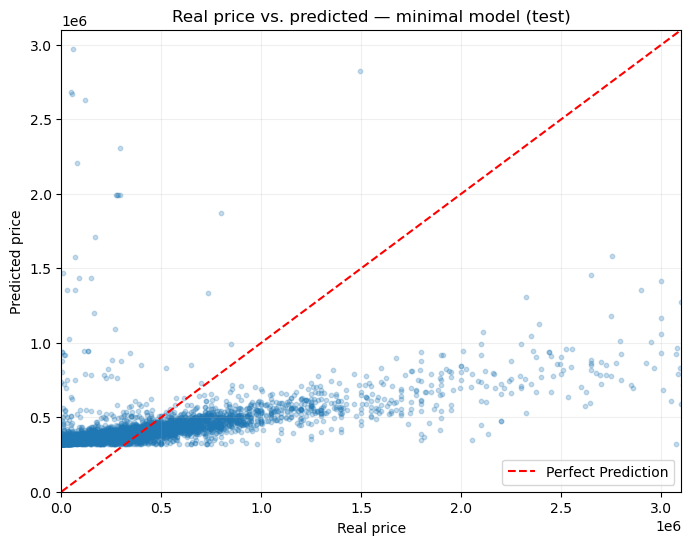

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Valores reales y predichos del mismo conjunto: entrenamiento
y_test_graph = y_test.to_numpy()


rng = np.random.default_rng(42)

indexs = rng.choice(len(y_test_graph),size=min(10_000, len(y_test_graph)),replace=False)

y_test_graph_muestra = y_test_graph[indexs]
y_test_minimal_pred_muestra = (y_test_minimal_pred[indexs])


minimal_limit = min(0,np.quantile(y_test_graph, 0.01),np.quantile(y_test_minimal_pred, 0.01))
maximal_limit = max(np.quantile(y_test_graph, 0.99),np.quantile(y_test_minimal_pred, 0.99))

plt.figure(figsize=(8, 6))
plt.scatter(y_test_graph_muestra,y_test_minimal_pred_muestra,alpha=0.25,s=10)
plt.plot([minimal_limit, maximal_limit],[minimal_limit, maximal_limit],'--',color='red',label='Perfect Prediction')

plt.xlim(minimal_limit, maximal_limit)
plt.ylim(minimal_limit, maximal_limit)

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title('Real price vs. predicted — minimal model (test)'
)

plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Some metrics 


In [16]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)


mae_minimal = mean_absolute_error(y_test,y_test_minimal_pred)
rmse_minimal = mean_squared_error(y_test,y_test_minimal_pred) ** 0.5
r2_minimal = r2_score(y_test,y_test_minimal_pred)

print("MAE:", mae_minimal)
print("RMSE:", rmse_minimal)
print("R²:", r2_minimal)

MAE: 280454.6368292131
RMSE: 1728183.545935925
R²: 0.17480298311919906


## Now lets try with Ridge

In [17]:
from sklearn.linear_model import Ridge

modelo_minimal = Ridge(
    alpha=1.0,
    solver='lsqr'
)

modelo_minimal.fit(X_train_minimal, y_train)

y_test_minimal_pred = modelo_minimal.predict(X_test_minimal)

### Graph with Ridge 

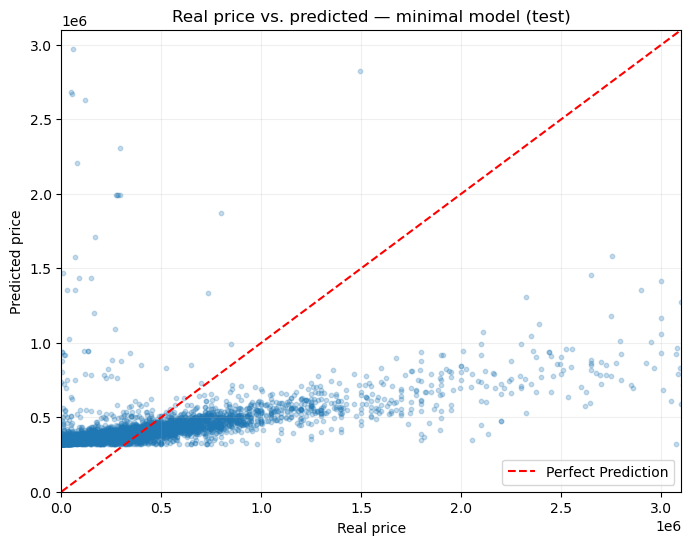

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Valores reales y predichos del mismo conjunto: entrenamiento
y_test_graph = y_test.to_numpy()


rng = np.random.default_rng(42)

indexs = rng.choice(len(y_test_graph),size=min(10_000, len(y_test_graph)),replace=False)

y_test_graph_muestra = y_test_graph[indexs]
y_test_minimal_pred_muestra = (y_test_minimal_pred[indexs])


minimal_limit = min(0,np.quantile(y_test_graph, 0.01),np.quantile(y_test_minimal_pred, 0.01))
maximal_limit = max(np.quantile(y_test_graph, 0.99),np.quantile(y_test_minimal_pred, 0.99))

plt.figure(figsize=(8, 6))
plt.scatter(y_test_graph_muestra,y_test_minimal_pred_muestra,alpha=0.25,s=10)
plt.plot([minimal_limit, maximal_limit],[minimal_limit, maximal_limit],'--',color='red',label='Perfect Prediction')

plt.xlim(minimal_limit, maximal_limit)
plt.ylim(minimal_limit, maximal_limit)

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title('Real price vs. predicted — minimal model (test)'
)

plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Metrics of Ridge

In [19]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)


mae_minimal = mean_absolute_error(y_test,y_test_minimal_pred)
rmse_minimal = mean_squared_error(y_test,y_test_minimal_pred) ** 0.5
r2_minimal = r2_score(y_test,y_test_minimal_pred)

print("MAE:", mae_minimal)
print("RMSE:", rmse_minimal)
print("R²:", r2_minimal)

MAE: 280454.6368292131
RMSE: 1728183.545935925
R²: 0.17480298311919906


## Lets start with EDA

In [20]:
print("This is the general structure of the dataset, lets remember")
print("Matrix with features")
X.head()




This is the general structure of the dataset, lets remember
Matrix with features


,Serial Number,List Year,Town,Assessed Value,Property Type,Residential Type,Year Recorded,Month Recorded,Day Recorded
0,24079,2024,Ashford,54460.0,Vacant Land,NaN,2025.0,9.0,26.0
1,240171,2024,Berlin,251400.0,Commercial,NaN,2025.0,6.0,6.0
2,24071,2024,Bethel,221480.0,Residential,Two Family,2024.0,12.0,31.0
3,24018,2024,Columbia,3640.0,Vacant Land,NaN,2024.0,12.0,18.0
4,240008,2024,Cromwell,96950.0,Residential,Condo,2024.0,10.0,11.0


Measures of central tendency

Variables of time (List Year, Year Recorded, Month Recorded, Day Recorded)


Variable List Year

Mean of the variable List Year:  2012.1635084024601
Count per year : 
 List Year
2001    59584
2002    59682
2003    64239
2004    84056
2005    61602
2006    48785
2007    35617
2008    32735
2009    42508
2010    33491
2011    31065
2012    35973
2013    39943
2014    49563
2015    46651
2016    49773
2017    45691
2018    50709
2019    58954
2020    66592
2021    56946
2022    43470
2023    44093
2024    47275
Name: count, dtype: int64

Variable Year Recorded

Mean of the variable Year Recorded:  2012.9078772245975
Count per year : 
 Year Recorded
1999.0        1
2001.0    14291
2002.0    60207
2003.0    56317
2004.0    73943
2005.0    79566
2006.0    57250
2007.0    46138
2008.0    34195
2009.0    36305
2010.0    39128
2011.0    32088
2012.0    32568
2013.0    37513
2014.0    41941
2015.0    48894
2016.0    47611
2017.0    48493
2018.0    47165
2019.0    52

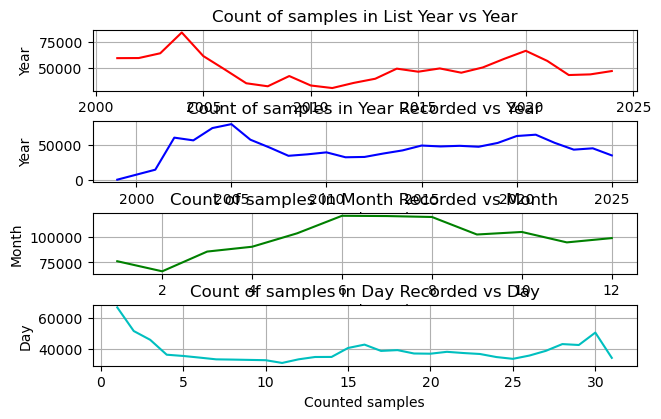

In [31]:
print("Measures of central tendency\n")
print("Variables of time (List Year, Year Recorded, Month Recorded, Day Recorded)\n")


plt.figure(1)


print("\nVariable List Year\n")
print("Mean of the variable List Year: ", X['List Year'].mean())

count_per_year_list_year = X['List Year'].value_counts().sort_index()
print("Count per year : \n", count_per_year_list_year)

plt.subplot(411)
plt.plot(count_per_year_list_year.index, count_per_year_list_year.values,'r') 
plt.title("Count of samples in List Year vs Year")
plt.ylabel("Year")
plt.xlabel("Counted samples")
plt.grid(True)

print("\nVariable Year Recorded\n")
print("Mean of the variable Year Recorded: ", X['Year Recorded'].mean())

count_per_year_year_recorded = X['Year Recorded'].value_counts().sort_index()
print("Count per year : \n", count_per_year_year_recorded)

plt.subplot(412)
plt.plot(count_per_year_year_recorded.index,count_per_year_year_recorded.values, 'b') 
plt.title("Count of samples in Year Recorded vs Year")
plt.ylabel("Year")
plt.xlabel("Counted samples")
plt.grid(True)

print("\nVariable Month Recorded\n")
print("Mean of the variable Year Recorded: ", X['Year Recorded'].mean())

count_per_year_month_recorded = X['Month Recorded'].value_counts().sort_index()
print("Count per year : \n", count_per_year_month_recorded)

plt.subplot(413)
plt.plot(count_per_year_month_recorded.index,count_per_year_month_recorded.values, 'g') 
plt.title("Count of samples in Month Recorded vs Month")
plt.ylabel("Month")
plt.xlabel("Counted samples")
plt.grid(True)


print("\nVariable Day Recorded\n")
print("Mean of the variable Day Recorded: ", X['Day Recorded'].mean())

count_per_year_day_recorded = X['Day Recorded'].value_counts().sort_index()
print("Count per year : \n", count_per_year_day_recorded)

plt.subplot(414)
plt.plot(count_per_year_day_recorded.index,count_per_year_day_recorded.values, 'c') 
plt.title("Count of samples in Day Recorded vs Day")
plt.ylabel("Day")
plt.xlabel("Counted samples")
plt.grid(True)

plt.subplots_adjust(top=0.9, bottom=0.2, left=0.10, right=0.95, hspace=0.5, wspace=1)
plt.show()
